## The effect of Stellar Temperature on Luminosity of Stars

This code is used to generate the results for the paper. 

### Load libraries

In [789]:
# --- must come before torch / rpy2 are imported -----------------------
import os
os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import sys, importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBRegressor
from econml.dml import CausalForestDML, NonParamDML

import torch
from torch import nn
from ganite import Ganite

# --- R / GRF ----------------------------------------------------------
import rpy2.robjects as ro
from rpy2.robjects import numpy2ri
from rpy2.robjects.conversion import localconverter
from rpy2.robjects.packages import importr

grf = importr('grf')

# --- local source -----------------------------------------------------
SRC = Path.cwd() / "src"
assert (SRC / "GBCcausal.py").exists(), f"src not found at {SRC}"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import GBCcausal
import simulations
importlib.reload(GBCcausal)      # reload first: simulations imports it
importlib.reload(simulations)

from GBCcausal import GenTE
from simulations import (simulate_causal_data,
                         simulate_causal_snr,
                         simulate_causal_assignments,
                         run_mc_simulations)

print(GBCcausal.__file__)
print(simulations.__file__)
print([n for n in dir(GBCcausal) if not n.startswith('_')])


# Create results directory if it doesn't exist
results_dir = 'results'
if not os.path.exists(results_dir):
    os.makedirs(results_dir)


SEED = 42



/Users/marnar/labrepos/generativeAI/src/GBCcausal.py
/Users/marnar/labrepos/generativeAI/src/simulations.py
['CausalIQN', 'CausalIQNv2', 'CosineAnnealingLR', 'GenTE', 'composite_loss', 'cosine_embed', 'get_device', 'nn', 'np', 'optim', 'torch', 'train_iqn']


## Estimate the effect of Stellar Temperature on Luminosity of Stars using Generative AI and GRF. 

Plot the raw densities first:

5776.0


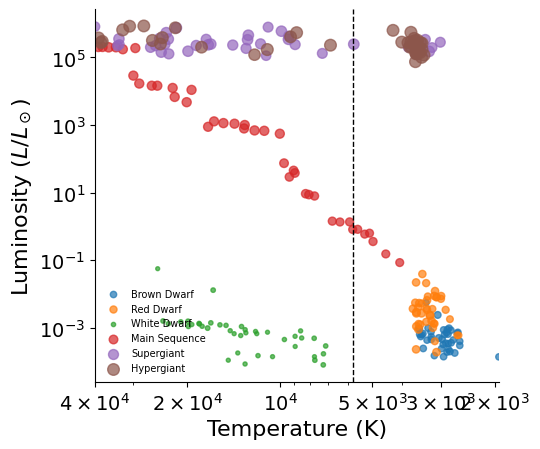

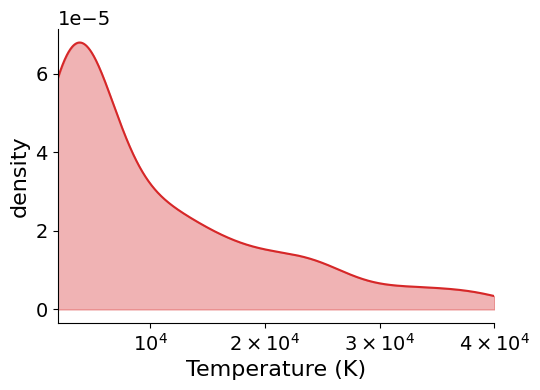

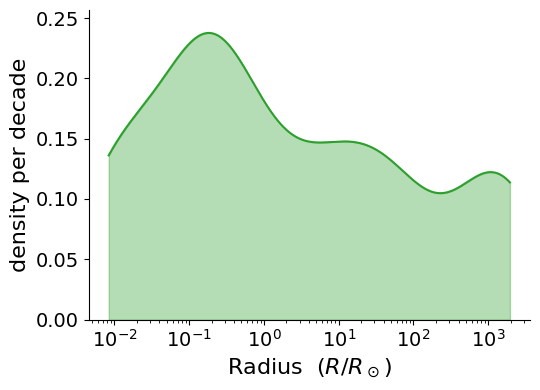

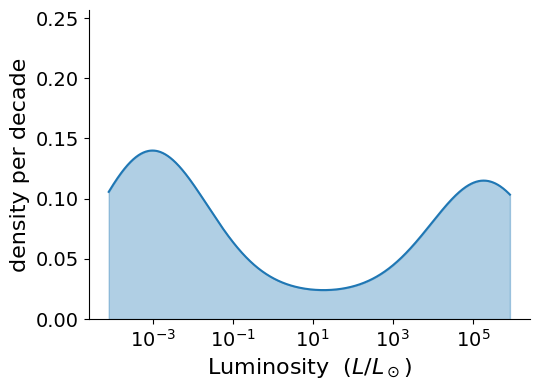

In [790]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

stars = pd.read_csv('Stars.csv')
T = stars['Temperature (K)'].to_numpy(float)
L = stars['Luminosity (L/Lo)'].to_numpy(float)
R = stars['Radius (R/Ro)'].to_numpy(float)
t_star = np.median(T)
print(t_star)
t_ticks = [2e3, 3e3, 5e3, 1e4, 2e4, 4e4]
t_ticklabels = [r'$2\times10^{3}$', r'$3\times10^{3}$', r'$5\times10^{3}$',
                r'$10^{4}$', r'$2\times10^{4}$', r'$4\times10^{4}$']
t_lim = (min(T.min(), t_ticks[0]), max(T.max(), t_ticks[-1]))

# (a) Hertzsprung-Russell diagram.
fig, ax = plt.subplots(figsize=(5.5, 4.6))
for cat, colour in zip(stars['Star category'].unique(), plt.cm.tab10.colors):
    m = (stars['Star category'] == cat).to_numpy()
    ax.scatter(T[m], L[m], s=8 + 12 * (np.log10(R[m]) - np.log10(R).min()),
               alpha=0.7, color=colour, label=cat)
ax.axvline(t_star, ls='--', c='k', lw=1)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(*t_lim)
ax.invert_xaxis()
ax.set_xticks(t_ticks)
ax.set_xticklabels(t_ticklabels)
ax.set_xlabel(r'Temperature (K)')
ax.set_ylabel(r'Luminosity ($L/L_\odot$)')
ax.legend(frameon=False, fontsize=7, loc='lower left')
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
fig.savefig(f'{results_dir}/star_hr_diagram.pdf', bbox_inches='tight')
plt.show()

# (b) Temperature, linear: it spans only a little over one decade.
# Same limits as the HR panel; linear ticks so labels do not pile up at 2e3.
t_ticks_lin = [1e4, 2e4, 3e4, 4e4]
t_ticklabels_lin = [r'$10^{4}$', r'$2\times10^{4}$', r'$3\times10^{4}$',
                    r'$4\times10^{4}$']
fig, ax = plt.subplots(figsize=(5.5, 4.0))
grid = np.linspace(t_lim[0], t_lim[1], 1000)
ax.fill_between(grid, gaussian_kde(T)(grid), color='C3', alpha=0.35)
ax.plot(grid, gaussian_kde(T)(grid), color='C3')
ax.set_xlim(*t_lim)
ax.set_xticks(t_ticks_lin)
ax.set_xticklabels(t_ticklabels_lin)
ax.set_xlabel(r'Temperature (K)')
ax.set_ylabel('density')
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
fig.savefig(f'{results_dir}/star_density_temperature.pdf', bbox_inches='tight')
plt.show()

# (c), (d) Radius and luminosity in original units on logarithmic axes.
# Both KDEs are densities of log10(value); share the vertical scale.
log_kdes = []
for values, label, stem, colour in [
    (R, r'Radius  ($R/R_\odot$)', 'radius',     'C2'),
    (L, r'Luminosity  ($L/L_\odot$)', 'luminosity', 'C0'),
]:
    lg = np.log10(values)
    grid = np.linspace(lg.min(), lg.max(), 1000)
    density = gaussian_kde(lg)(grid)
    log_kdes.append((10 ** grid, density, label, stem, colour))

ymax = 1.08 * max(density.max() for _, density, _, _, _ in log_kdes)
for x, density, label, stem, colour in log_kdes:
    fig, ax = plt.subplots(figsize=(5.5, 4.0))
    ax.fill_between(x, density, color=colour, alpha=0.35)
    ax.plot(x, density, color=colour)
    ax.set_xscale('log')
    ax.set_ylim(0, ymax)
    ax.set_xlabel(label)
    ax.set_ylabel('density per decade')
    ax.spines[['top', 'right']].set_visible(False)
    fig.tight_layout()
    fig.savefig(f'{results_dir}/star_density_{stem}.pdf', bbox_inches='tight')
    plt.show()

# Run GRF and GenTE

Load covariates:

In [791]:
import helpers_star
importlib.reload(helpers_star)
from helpers_star import (fit_stars_grf_gente, 
                        load_and_split_star_data, 
                        load_and_split_star_data_covariates)
                        
(X_train, D_train, Y_train, X_test, D_test, Y_test,
 Y_train_std, Y_test_std, y_loc, y_scale,
 T_train, T_test, R_train, R_test,
 cat_train, cat_test) = load_and_split_star_data_covariates(
    test_size=0.5, feature_set='full')

(X_train_ra, D_train_ra, Y_train_ra, X_test_ra, D_test_ra, Y_test_ra,
 Y_train_std_ra, Y_test_std_ra, y_loc_ra, y_scale_ra,
 T_train_ra, T_test_ra, R_train_ra, R_test_ra,
 cat_train_ra, cat_test_ra) = load_and_split_star_data_covariates(
    test_size=0.5, feature_set='radius')

print('full  :', X_train.shape, '->', X_test.shape)
print('radius:', X_train_ra.shape, '->', X_test_ra.shape)
print('same split:', np.array_equal(D_train, D_train_ra),
      np.array_equal(R_test, R_test_ra))

Dataset loaded successfully
Raw data shape: (240, 8)
Available columns: ['Temperature (K)', 'Luminosity (L/Lo)', 'Radius (R/Ro)', 'Absolute magnitude (Mv)', 'Star type', 'Star category', 'Star color', 'Spectral Class']

Observations and treated share by Star category:
               size  mean
cat                      
Brown Dwarf      40  0.00
Hypergiant       40  0.40
Main Sequence    40  0.85
Red Dwarf        40  0.00
Supergiant       40  0.75
White Dwarf      40  1.00

Dataset Summary:
Feature set: full
Training samples: 120
Test samples: 120

Observations by size, train:
Star category
Brown Dwarf      17
Hypergiant       29
Main Sequence    19
Red Dwarf        18
Supergiant       17
White Dwarf      20

Observations by size, test:
Star category
Brown Dwarf      23
Hypergiant       11
Main Sequence    21
Red Dwarf        22
Supergiant       23
White Dwarf      20
Features (26): ['Radius (R/Ro)', 'color_blue', 'color_blue white', 'color_orange', 'color_orange red', 'color_pale yello

In [792]:

res = fit_stars_grf_gente(X_train, Y_train, D_train, X_test, D_test, 
                        verbose = True, 
                        learning_rate = 0.01, 
                        wd = 0, 
                        target = 'mean')
tau_gen_test = res['tau_gen_test']
tau_grf_test = res['tau_grf_test']
L_hat = res['L_hat']


print('Y_test  range: %.3g to %.3g  (%.1f decades)'
      % (Y_test.min(), Y_test.max(), np.log10(Y_test.max()/max(Y_test.min(),1e-12))))
print('L_hat   range: %.3g to %.3g  (%.1f decades)'
      % (L_hat.min(), L_hat.max(), np.log10(L_hat.max()/max(L_hat.min(),1e-12))))
print('corr(log L_hat, log Y_test) =',
      np.corrcoef(np.log(np.clip(L_hat,1e-12,None)), np.log(Y_test))[0,1])
print('y_loc = %.4g, y_scale = %.4g' % (y_loc, y_scale))


Training GRF model...
Training GenTE...

Test Set Results:
GRF:
Average Treatment Effect: -115468.96
Standard Deviation: 49705.43

GenTE (estimate_cate):
Average Treatment Effect: 19412.48
ATE SE: 19356.05
ATE 95% CI: (-1078.08, 57493.64)
CATE SD: 32732.68
Min: 0.0597  
Y_test  range: 8.5e-05 to 8.13e+05  (10.0 decades)
L_hat   range: 0.101 to 5.44e+05  (6.7 decades)
corr(log L_hat, log Y_test) = 0.945914139238649
y_loc = 1.227e+05, y_scale = 1.837e+05


Now fit only with radius and log radius as covariates:

In [793]:
res_ra = fit_stars_grf_gente(X_train_ra, Y_train_ra, D_train_ra, X_test_ra, D_test_ra, 
                        verbose = True, 
                        learning_rate = 0.006, 
                        wd = 0, 
                        target = 'mean')
tau_gen_test_ra = res_ra['tau_gen_test']
tau_grf_test_ra = res_ra['tau_grf_test']
L_hat_ra = res_ra['L_hat']


print('Y_test  range: %.3g to %.3g  (%.1f decades)'
      % (Y_test_ra.min(), Y_test_ra.max(), np.log10(Y_test_ra.max()/max(Y_test_ra.min(),1e-12))))
print('L_hat   range: %.3g to %.3g  (%.1f decades)'
      % (L_hat_ra.min(), L_hat_ra.max(), np.log10(L_hat_ra.max()/max(L_hat_ra.min(),1e-12))))
print('corr(log L_hat, log Y_test) =',
      np.corrcoef(np.log(np.clip(L_hat_ra,1e-12,None)), np.log(Y_test_ra))[0,1])
print('y_loc = %.4g, y_scale = %.4g' % (y_loc_ra, y_scale_ra))


Training GRF model...
Training GenTE...

Test Set Results:
GRF:
Average Treatment Effect: 70055.28
Standard Deviation: 45522.40

GenTE (estimate_cate):
Average Treatment Effect: 23776.67
ATE SE: 14229.10
ATE 95% CI: (12525.06, 64934.52)
CATE SD: 50251.05
Min: 0.7021  
Y_test  range: 8.5e-05 to 8.13e+05  (10.0 decades)
L_hat   range: 0.97 to 5.15e+05  (5.7 decades)
corr(log L_hat, log Y_test) = 0.978640420397291
y_loc = 1.227e+05, y_scale = 1.837e+05


: n = 120 of 120 plotted (0.0% dropped, L_hat <= 0)
  corr(log L_hat, log Y) = 0.9459,  R2 = 0.8948
  L_hat range 0.101 to 5.44e+05  |  Y range 8.5e-05 to 8.13e+05


/Users/marnar/labrepos/generativeAI/src/helpers_star.py:872: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


  saved plots/Lhat_vs_Ytest_full.pdf
  saved plots/Lhat_vs_Ytest_full.png


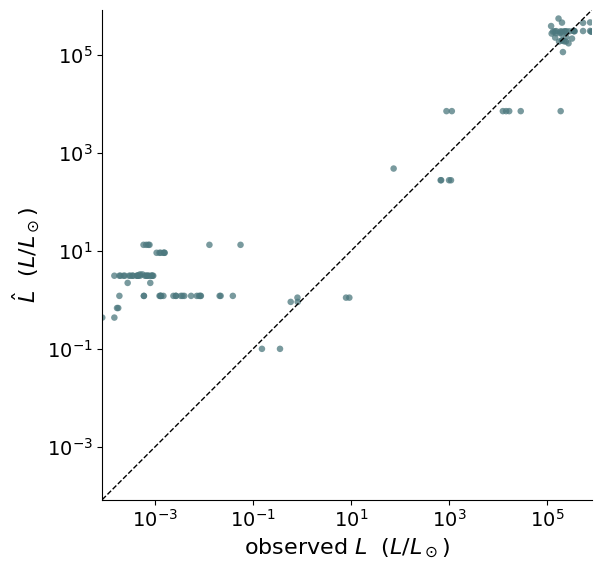

: n = 120 of 120 plotted (0.0% dropped, L_hat <= 0)
  corr(log L_hat, log Y) = 0.9786,  R2 = 0.9577
  L_hat range 0.97 to 5.15e+05  |  Y range 8.5e-05 to 8.13e+05
  saved plots/Lhat_vs_Ytest_radius.pdf
  saved plots/Lhat_vs_Ytest_radius.png


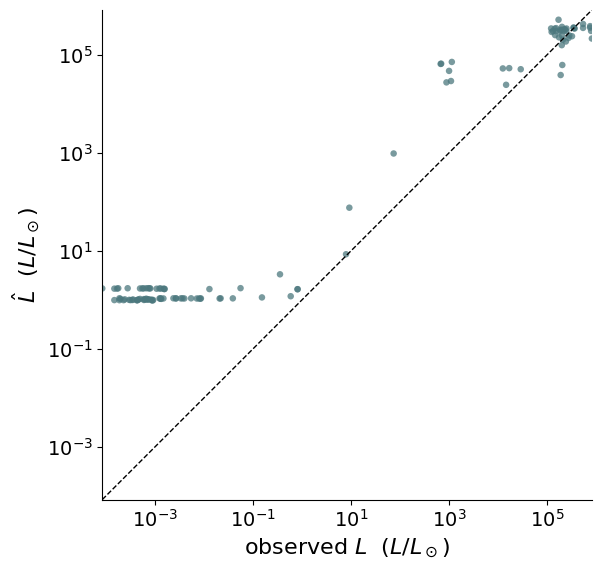

[np.float64(8.5e-05), np.float64(813000.0)]

In [806]:
import helpers_star
importlib.reload(helpers_star)
from helpers_star import plot_fit_scatter
y_all = np.concatenate([np.asarray(Y_test, float), np.asarray(Y_test_ra, float)])
f_all = np.concatenate([L_hat, L_hat_ra])
ok = (y_all > 0) & (f_all > 0)
lim = [min(y_all[ok].min(), f_all[ok].min()),
       max(y_all[ok].max(), f_all[ok].max())]

plot_fit_scatter(Y_test,    L_hat,    name='',
                 stem='Lhat_vs_Ytest_full',   lim=lim)
plot_fit_scatter(Y_test_ra, L_hat_ra, name='',
                 stem='Lhat_vs_Ytest_radius', lim=lim)

## Density plot for the effect of Stellar Temperature on Luminosity of Stars (Generative AI)

  saved plots/treatment_effects_density.pdf
  saved plots/treatment_effects_density.png


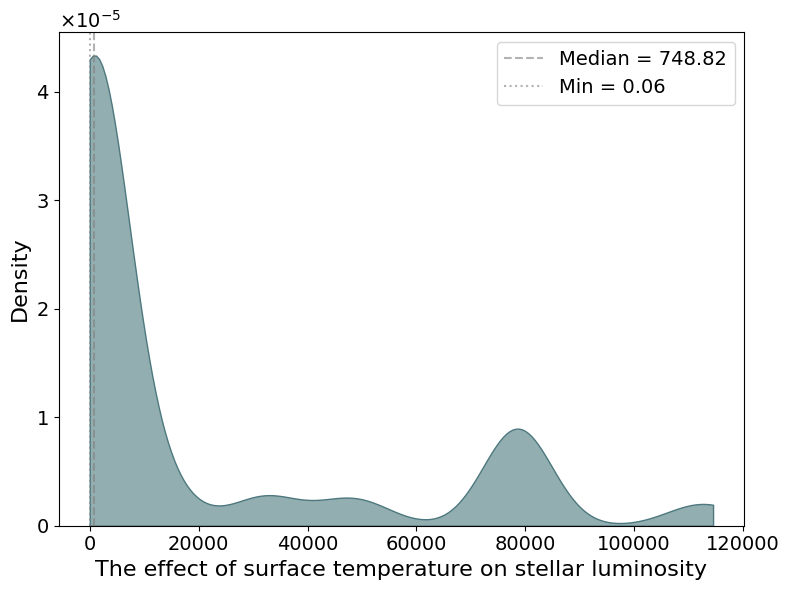

  saved plots/treatment_effects_density_grf.pdf
  saved plots/treatment_effects_density_grf.png


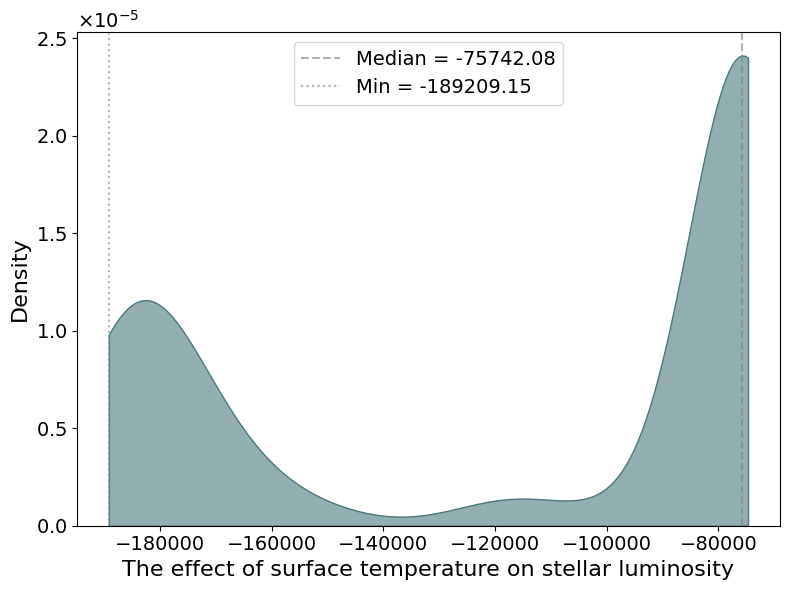

  saved plots/treatment_effects_density_ra.pdf
  saved plots/treatment_effects_density_ra.png


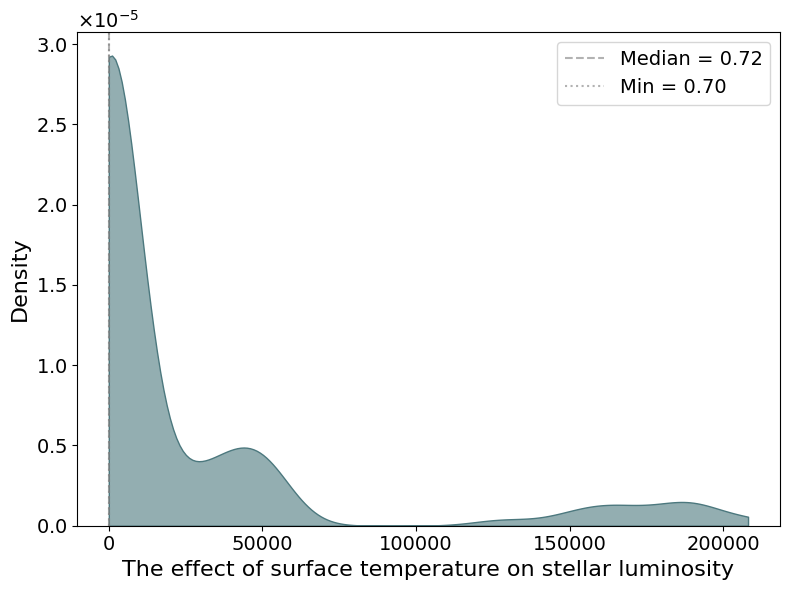

  saved plots/treatment_effects_density_grf_ra.pdf
  saved plots/treatment_effects_density_grf_ra.png


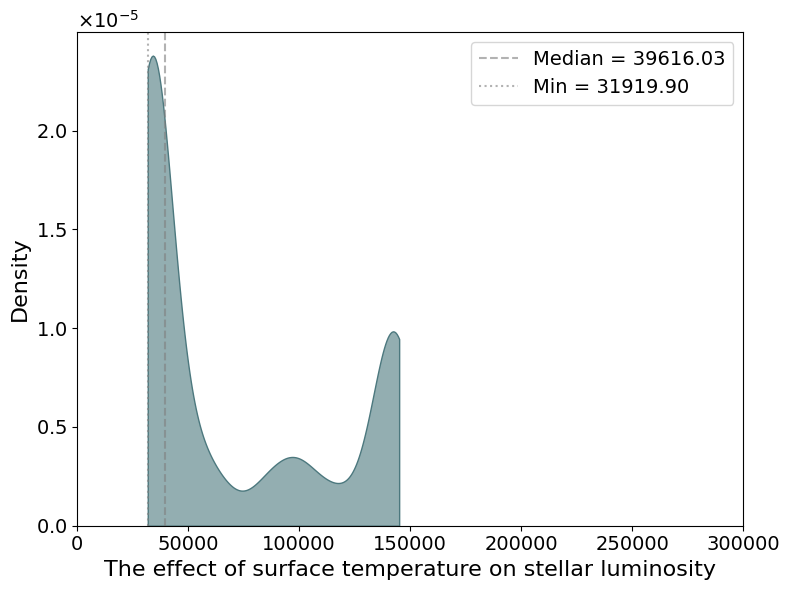

In [805]:
import helpers_star
importlib.reload(helpers_star)
from helpers_star import plot_effect_density
s_gen = plot_effect_density(tau_gen_test, name='GenTE (test)',
                            stem='treatment_effects_density')
s_grf = plot_effect_density(tau_grf_test, name='GRF (test)',
                            stem='treatment_effects_density_grf')


s_gen_ra = plot_effect_density(tau_gen_test_ra, name='GenTE (test)',
                            stem='treatment_effects_density_ra')
s_grf_ra = plot_effect_density(tau_grf_test_ra, name='GRF (test)',
                            stem='treatment_effects_density_grf_ra', 
                            xlim=(0, 300000))

# Test

Regress predicted log(L_hat) on log(R/R_0) Fourth power of log(T/T_0). The slopes must be 2 and 4. 

In [796]:
import helpers_star
importlib.reload(helpers_star)
from helpers_star import sb_regression
tab = pd.concat([
    sb_regression(Y_test,   R_test,    T_test,    'observed L (control)'),
    sb_regression(L_hat,    R_test,    T_test,    'GenTE, full covariates'),
    sb_regression(L_hat_ra, R_test_ra, T_test_ra, 'GenTE, radius only'),
], ignore_index=True)

cols = ['name', 'n', 'Intercept_est', 'log_R_est', 'log_T_est', 'R2',
        'F', 'F_pvalue']
print(tab[cols].to_string(index=False))



--- observed L (control)  (n = 120)
term           law      est      se              95% CI  t vs law       p    
Intercept        0   -0.452   0.194    [-0.836, -0.068]     -2.33   0.022  *
log_R            2    2.091   0.054      [1.984, 2.198]      1.68   0.096
log_T            4    3.545   0.222      [3.106, 3.985]     -2.05   0.043  *
R2 = 0.948   joint F(3, 117) = 4.71, p = 0.00386
  * interval excludes the value the law implies

--- GenTE, full covariates  (n = 120)
term           law      est      se              95% CI  t vs law       p    
Intercept        0    4.208   0.194      [3.824, 4.592]     21.69   0.000  *
log_R            2    1.181   0.054      [1.074, 1.288]    -15.18   0.000  *
log_T            4    2.224   0.222      [1.785, 2.663]     -8.00   0.000  *
R2 = 0.860   joint F(3, 117) = 247.72, p = 1.67e-50
  * interval excludes the value the law implies

--- GenTE, radius only  (n = 120)
term           law      est      se              95% CI  t vs law       p    


In [799]:
import numpy as np, pandas as pd

d = pd.read_csv('Stars.csv')
T = d['Temperature (K)'].to_numpy(float)
D = (T > np.median(T)).astype(int)

for col in ['Spectral Class', 'Star color', 'Star category']:
    v = (d[col].astype(str).str.strip().str.lower()
         .str.replace(r'[-_]', ' ', regex=True)
         .str.replace(r'\s+', ' ', regex=True))
    g = pd.DataFrame({'v': v, 'D': D}).groupby('v')['D'].agg(['size', 'sum', 'mean'])
    g.columns = ['n', 'treated', 'share']
    deg = g.loc[(g['share'] == 0) | (g['share'] == 1), 'n'].sum()
    print(f"--- {col}: {deg}/{len(d)} stars ({100*deg/len(d):.0f}%) "
          f"in levels where D is deterministic")
    print(g.sort_values('share').to_string(), '\n')

--- Spectral Class: 183/240 stars (76%) in levels where D is deterministic
     n  treated     share
v                        
k    6        0  0.000000
m  111        0  0.000000
f   17       15  0.882353
o   40       39  0.975000
a   19       19  1.000000
b   46       46  1.000000
g    1        1  1.000000 

--- Star color: 64/240 stars (27%) in levels where D is deterministic
                      n  treated     share
v                                         
orange                2        0  0.000000
orange red            1        0  0.000000
yellowish             3        0  0.000000
red                 112        1  0.008929
yellow white          8        6  0.750000
blue                 56       55  0.982143
blue white           41       41  1.000000
pale yellow orange    1        1  1.000000
white                10       10  1.000000
white yellow          1        1  1.000000
whitish               2        2  1.000000
yellowish white       3        3  1.000000 

--- Star catego

## Studying The Effect Heterogeneity

shared ylim: 4.25e-05 to 1.63e+06
  saved plots/star_heatmap_TL.pdf
  saved plots/star_heatmap_TL.png


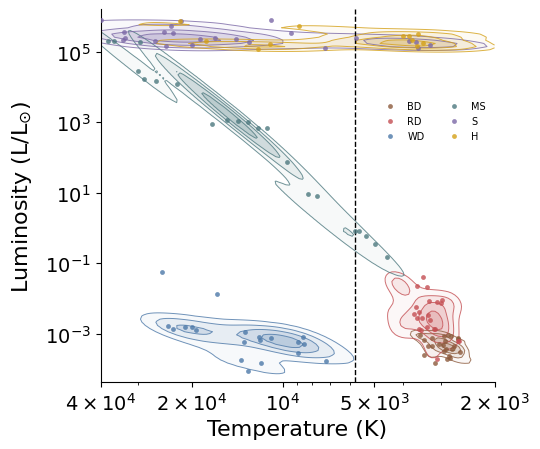

  saved plots/star_heatmap_Ttau.pdf
  saved plots/star_heatmap_Ttau.png


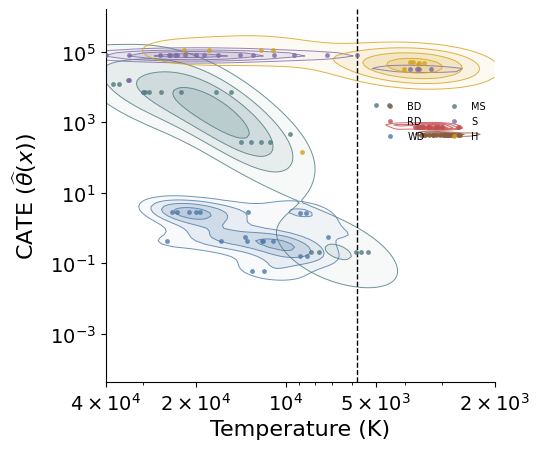

  saved plots/star_heatmap_TL_ra.pdf
  saved plots/star_heatmap_TL_ra.png


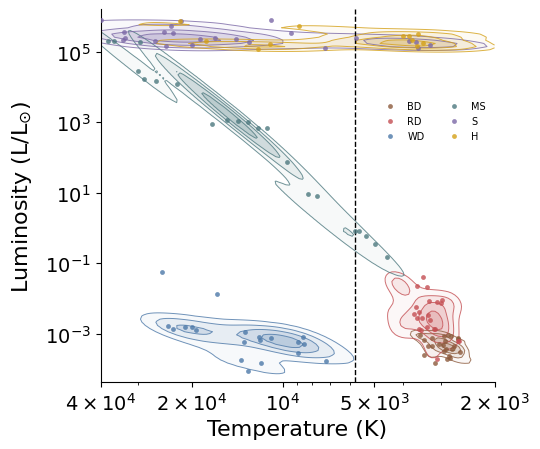

  saved plots/star_heatmap_Ttau_ra.pdf
  saved plots/star_heatmap_Ttau_ra.png


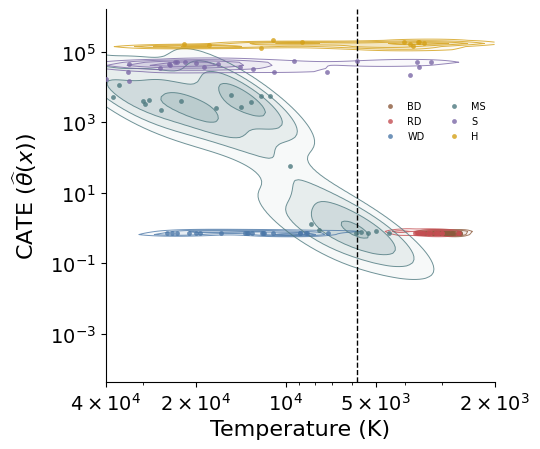

In [802]:

import helpers_star
importlib.reload(helpers_star) 
from helpers_star import plot_star_heatmaps


def _pos(a):
    a = np.asarray(a, float)
    return a[np.isfinite(a) & (a > 0)]

tau_floor = 1e-2
vals = np.concatenate([
    _pos(Y_test),
    _pos(np.where(np.asarray(tau_gen_test, float) > 0, tau_gen_test, tau_floor)),
    _pos(np.where(np.asarray(tau_gen_test_ra, float) > 0, tau_gen_test_ra, tau_floor)),
])
ylim = (vals.min() * 0.5, vals.max() * 2)
print('shared ylim: %.3g to %.3g' % ylim)

# full covariates -- panels (a) and (b)
plot_star_heatmaps(T_test, Y_test, tau_gen_test, cat_test,
                   t_cut=t_star, results_dir='plots',
                   stems=('star_heatmap_TL', 'star_heatmap_Ttau'),
                   tau_floor=tau_floor, ylim=ylim)

# radius only -- panel (c)
plot_star_heatmaps(T_test_ra, Y_test_ra, tau_gen_test_ra, cat_test_ra,
                   t_cut=t_star, results_dir='plots',
                   stems=('star_heatmap_TL_ra', 'star_heatmap_Ttau_ra'),
                   tau_floor=tau_floor, ylim=ylim)



# Propensity Scores

In [809]:
def run_star_propensity(
    # ---- data: full covariate set ---------------------------------
    X_train, D_train, Y_train_std, X_test, D_test,
    cat_test, R_test, T_test,
    # ---- data: radius-only covariate set --------------------------
    X_train_ra, D_train_ra, Y_train_std_ra, X_test_ra, D_test_ra,
    cat_test_ra, R_test_ra, T_test_ra,
    # ---- output ---------------------------------------------------
    labels=('full', 'radius'),
    results_dir='results_stars',
    table_name='df_table_propensity',
    scores_name='propensity_scores',
    plot_name='hist_propensity',
    save_table=True,
    save_plots=True,
    plot_show=True,
    # ---- design ---------------------------------------------------
    tol=0.05,
    seed=SEED,
    # ---- estimator -------------------------------------------------
    gente_kwargs=None,          # passed to GenTE(...)
    gente_fit_kwargs=None,      # passed to .fit(...)
    # ---- cosmetics -------------------------------------------------
    colour='#4C787E',
    figsize=(11, 4.2),
    bins=25,
    verbose=True,
):
    """Estimated propensity scores on the held-out stars.

    Fits GenTE on the training half of each covariate set and predicts
    pi(x) on the corresponding test half.  A star is counted as lacking
    common support when pi_hat lies below ``tol`` or above ``1 - tol``.

    Returns
    -------
    dict with 'summary' (one row per covariate set and category),
    'overall' (one row per covariate set), 'scores' (one row per
    held-out star) and 'models' (the fitted ensembles).
    """
    gente_kwargs = {'model_cls': GBCcausal.CausalIQN, 'n_models': 3,
                    'device': 'auto', 'target': 'mean',
                    'hsz': 64, 'nh': 32, **(gente_kwargs or {})}
    gente_fit_kwargs = {'epochs': 3000, 'lr': 0.006, 'weight_decay': 1e-3,
                        'verbose': False, **(gente_fit_kwargs or {})}

    os.makedirs(results_dir, exist_ok=True)

    datasets = {
        labels[0]: (X_train, D_train, Y_train,
                    X_test, D_test, cat_test, R_test, T_test),
        labels[1]: (X_train_ra, D_train_ra, Y_train_ra,
                    X_test_ra, D_test_ra, cat_test_ra,
                    R_test_ra, T_test_ra),
    }

    rows, overall, scores, models = [], [], [], {}

    for name, (Xtr, Dtr, Ytr, Xte, Dte, cate, Rte, Tte) in datasets.items():
        if verbose:
            print(f"\n=== {name} covariates "
                  f"({Xtr.shape[1]} features) ===", flush=True)

        kw = dict(gente_kwargs)
        hsz, nh = kw.pop('hsz'), kw.pop('nh')
        torch.manual_seed(seed)
        ens = GenTE(model_kwargs={'xdim': Xtr.shape[1],
                                  'hsz': hsz, 'nh': nh}, **kw)
        ens.fit(Xtr, Ytr, Dtr, **gente_fit_kwargs)
        models[name] = ens

        pi_hat = ens.predict_propensity(Xte)
        outside = (pi_hat < tol) | (pi_hat > 1 - tol)

        for s in range(len(pi_hat)):
            scores.append({'covariates': name,
                           'category': cate[s],
                           'D': float(Dte[s]),
                           'radius': float(Rte[s]),
                           'temperature': float(Tte[s]),
                           'pi_hat': float(pi_hat[s]),
                           'no_support': bool(outside[s])})

        df_s = pd.DataFrame({'cat': cate, 'D': Dte,
                             'pi': pi_hat, 'out': outside})
        for cat, sub in df_s.groupby('cat'):
            rows.append({
                'covariates': name,
                'category': cat,
                'n': len(sub),
                'share treated': sub['D'].mean(),
                'pi min': sub['pi'].min(),
                'pi median': sub['pi'].median(),
                'pi max': sub['pi'].max(),
                f'share outside [{tol:g}, {1 - tol:g}]': sub['out'].mean(),
            })

        overall.append({
            'covariates': name,
            'n': len(pi_hat),
            'share treated': float(np.mean(Dte)),
            'pi min': float(pi_hat.min()),
            'pi median': float(np.median(pi_hat)),
            'pi max': float(pi_hat.max()),
            'n outside': int(outside.sum()),
            'share outside': float(outside.mean()),
        })

        if verbose:
            print(f"  pi in [{pi_hat.min():.3f}, {pi_hat.max():.3f}], "
                  f"{outside.sum()} of {len(pi_hat)} stars "
                  f"({outside.mean():.1%}) outside "
                  f"[{tol:g}, {1 - tol:g}]")

    df_summary = pd.DataFrame(rows)
    df_overall = pd.DataFrame(overall)
    df_scores = pd.DataFrame(scores)

    if save_table:
        p1 = os.path.join(results_dir, f'{table_name}.csv')
        p2 = os.path.join(results_dir, f'{table_name}_overall.csv')
        p3 = os.path.join(results_dir, f'{scores_name}.csv')
        df_summary.to_csv(p1, index=False)
        df_overall.to_csv(p2, index=False)
        df_scores.to_csv(p3, index=False)
        if verbose:
            print(f"\nsaved {p1}\nsaved {p2}\nsaved {p3}")

    # ------------------------------------------------------------------
    # one panel per covariate set, no-support region shaded
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)
    for ax, name in zip(axes, datasets):
        pi_hat = df_scores.loc[df_scores['covariates'] == name,
                               'pi_hat'].to_numpy()
        share = df_overall.loc[df_overall['covariates'] == name,
                               'share outside'].iloc[0]
        ax.axvspan(0, tol, color='0.88', zorder=0)
        ax.axvspan(1 - tol, 1, color='0.88', zorder=0)
        ax.hist(pi_hat, bins=bins, range=(0, 1), color=colour,
                alpha=0.85, edgecolor='white', linewidth=0.5, zorder=2)
        ax.set_xlim(0, 1)
        ax.set_xlabel(r'$\hat{\pi}(x)$')
        ax.set_title(f'{name} covariates    '
                     f'({share:.0%} without common support)',
                     fontsize=10)
    axes[0].set_ylabel('Held-out stars')
    fig.tight_layout()

    if save_plots:
        for ext in ('pdf', 'png'):
            path = os.path.join(results_dir, f'{plot_name}.{ext}')
            fig.savefig(path, dpi=300, bbox_inches='tight')
            if verbose:
                print(f"saved {path}")
    if plot_show:
        display(fig)
    plt.close(fig)

    if verbose:
        print()
        print(df_overall.to_string(index=False))
        print()
        print(df_summary.to_string(index=False))

    return {'summary': df_summary, 'overall': df_overall,
            'scores': df_scores, 'models': models}




=== full covariates (26 features) ===
  pi in [0.494, 0.626], 0 of 120 stars (0.0%) outside [0.05, 0.95]

=== radius covariates (2 features) ===
  pi in [0.498, 0.499], 0 of 120 stars (0.0%) outside [0.05, 0.95]

saved results_stars/df_table_propensity.csv
saved results_stars/df_table_propensity_overall.csv
saved results_stars/propensity_scores.csv
saved results_stars/hist_propensity.pdf
saved results_stars/hist_propensity.png


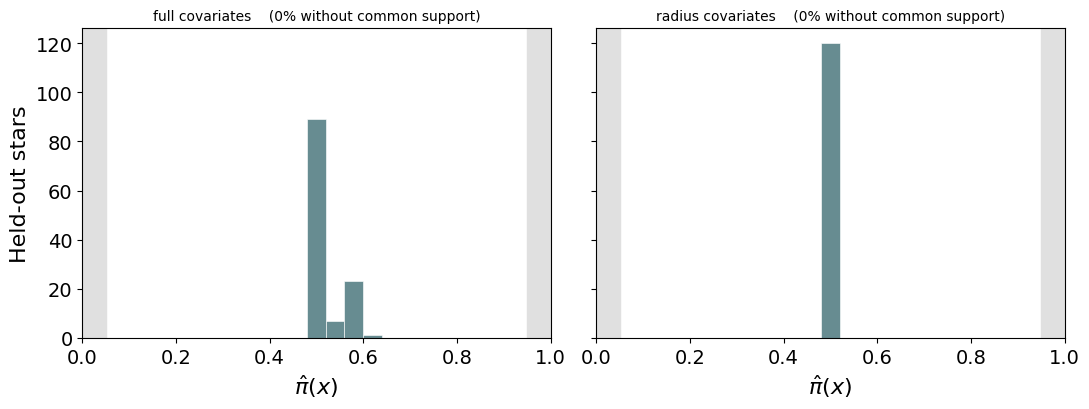


covariates   n  share treated   pi min  pi median   pi max  n outside  share outside
      full 120            0.5 0.493573   0.503516 0.626415          0            0.0
    radius 120            0.5 0.498183   0.498370 0.499493          0            0.0

covariates      category  n  share treated   pi min  pi median   pi max  share outside [0.05, 0.95]
      full   Brown Dwarf 23       0.000000 0.496143   0.496144 0.496144                         0.0
      full    Hypergiant 11       0.454545 0.493573   0.529060 0.626415                         0.0
      full Main Sequence 21       0.809524 0.500583   0.504406 0.568626                         0.0
      full     Red Dwarf 22       0.000000 0.495882   0.495884 0.495885                         0.0
      full    Supergiant 23       0.782609 0.525138   0.588992 0.590487                         0.0
      full   White Dwarf 20       1.000000 0.502594   0.504335 0.504403                         0.0
    radius   Brown Dwarf 23       0.000000 

In [810]:
res_pi = run_star_propensity(
    X_train, D_train, Y_train_std, X_test, D_test,
    cat_test, R_test, T_test,
    X_train_ra, D_train_ra, Y_train_std_ra, X_test_ra, D_test_ra,
    cat_test_ra, R_test_ra, T_test_ra,
    plot_show=True,
)


=== full (26 features) ===
  accuracy 1.000 train, 0.975 test
  pi in [0.007, 0.994], 120 of 120 stars (100.0%) outside [0.05, 0.95]

=== radius (2 features) ===
  accuracy 0.425 train, 0.367 test
  pi in [0.353, 0.566], 0 of 120 stars (0.0%) outside [0.05, 0.95]

saved plots/df_table_propensity_logit.csv
saved plots/df_table_propensity_logit_overall.csv
saved plots/propensity_scores_logit.csv
saved plots/hist_propensity_logit_full.pdf
saved plots/hist_propensity_logit_full.png


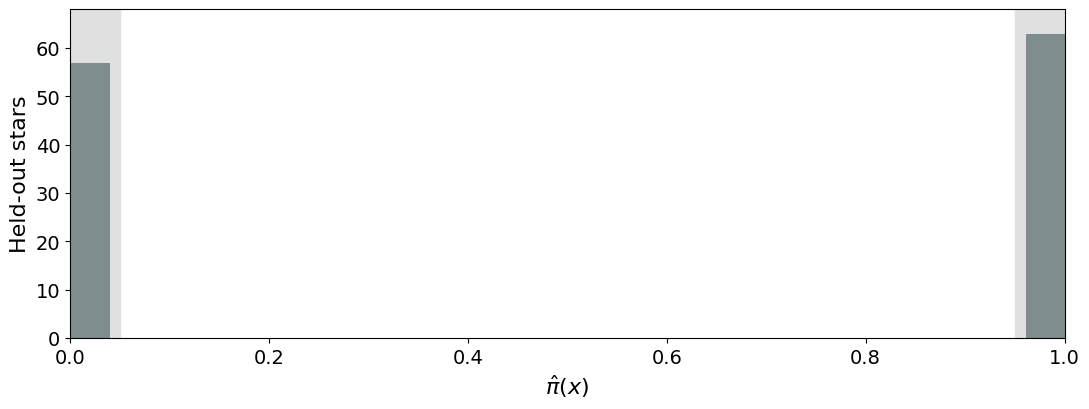

saved plots/hist_propensity_logit_radius.pdf
saved plots/hist_propensity_logit_radius.png


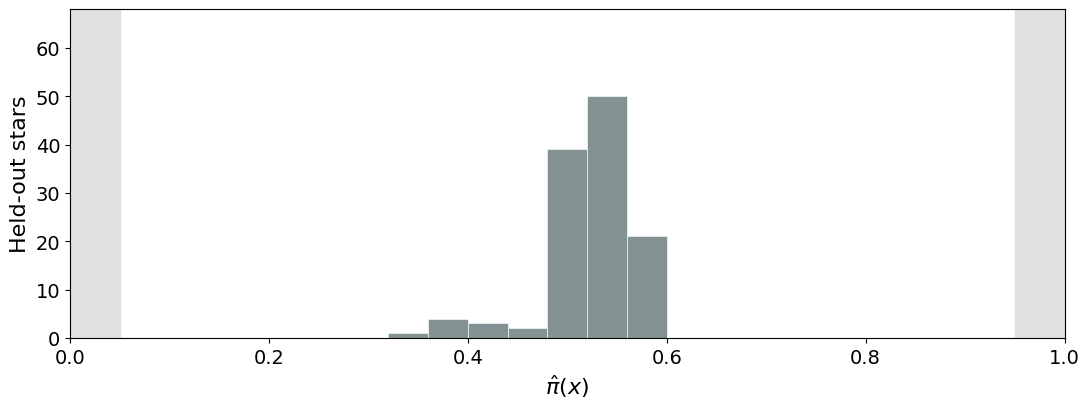

saved plots/hist_propensity_logit.pdf
saved plots/hist_propensity_logit.png


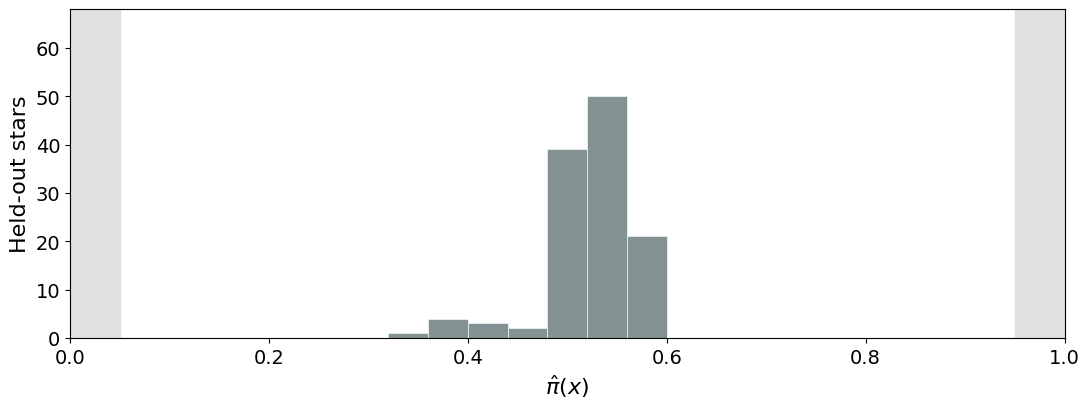


covariates   n  share treated  accuracy train  accuracy test   pi min  pi median   pi max  n outside  share outside
      full 120            0.5           1.000       0.975000 0.007077   0.975824 0.994111        120            1.0
    radius 120            0.5           0.425       0.366667 0.353450   0.526937 0.565896          0            0.0

covariates      category  n  share treated   pi min  pi median   pi max  share outside [0.05, 0.95]
      full   Brown Dwarf 23       0.000000 0.007112   0.007112 0.007112                         1.0
      full    Hypergiant 11       0.454545 0.013781   0.015614 0.983361                         1.0
      full Main Sequence 21       0.809524 0.023165   0.990623 0.994066                         1.0
      full     Red Dwarf 22       0.000000 0.007077   0.007077 0.007077                         1.0
      full    Supergiant 23       0.782609 0.022703   0.988658 0.988703                         1.0
      full   White Dwarf 20       1.000000 0.98944

In [828]:
import helpers_star
importlib.reload(helpers_star)
from helpers_star import run_star_propensity_logit

res_pi_logit = run_star_propensity_logit(
    X_train, D_train, X_test, D_test, cat_test, R_test, T_test,
    X_train_ra, D_train_ra, X_test_ra, D_test_ra,
    cat_test_ra, R_test_ra, T_test_ra,
    plot_show=True,
)

# CATEs across quantiles